In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
#import pdb; pdb.set_trace()

from quaternion import * 
from constants import *


# Just get a mock wind velocity function, later try to include a the real one, potentially by integrating rocket pi 
def wind_velocity(y, t):
    # return np.array([5 * (1 - np.exp(-y / 1000)), 0, 0])
    return 0


def rocket_forces(t, state, params):
    #set up state variables
    position = state[0:3]
    velocity = state[3:6]
    q = state[6:10]
    angular_velocity = state[10:13]
    
    current_mass = params['dry_mass'] + max(0, params['fuel_initial'] - params['burn_rate'] * t)
    I_body = params['I_body']
    
    rho = rho0 * np.exp(-position[2] / 8500)  # density of air at altitude
    
    R = quaternion_to_rotation_matrix(q) #get rotation matrix from quaternion
    
    # Find the wind velocity in the body frame
    #wind_velocity_body = R.T @ (velocity - wind_velocity(position, t))
    
    altitude = position[2]
    wind_east = 5 * (1 - np.exp(-position[2] / 1000))
    wind = np.array([wind_east, 0, 0])
    wind_velocity_body = R.T @ (velocity - wind)  # wind velocity in the body frame
    
    wind_speed = np.linalg.norm(wind_velocity_body)
    if wind_speed < 1e-6:
        wind_speed = 1e-6
    
    # Aerodynamic angles
    #alpha = np.arctan2(v_air_body[2], v_air_body[0])
    #beta = np.arcsin(v_air_body[1] / v_mag)
    
    # Calculate all forces and moments in the body frame
    
    # Main body drag
    drag_body = -0.5 * rho * wind_speed * wind_velocity_body * params['Cd_body'] * params['A_ref']
    
    F_total = np.zeros(3)
    M_total = np.zeros(3)
    
    # Cannards Drag
    
    for i in range(params['Num_cannards']):
        
        azimuth = i * 2 * np.pi / params['Num_cannards']
        
        x = params['canard_vertical_position'] 
        y = params['rocket_radius'] * np.cos(azimuth)
        z = params['rocket_radius'] * np.sin(azimuth)
        canard_position = np.array([x, y, z])
        
        # along which plane is the cannard area going to point 
        canard_vector = np.array([0, np.cos(params['canard_angles'][i]), np.sin(params['canard_angles'][i])])
        #canard_vector = canard_vector / np.linalg.norm(canard_vector)
        
        M_canard = np.cross(canard_position, canard_vector)
        F_canard = -0.5 * rho * wind_speed**2 * params['A_canard'] * canard_vector
        F_total += F_canard
        M_total += M_canard
    
    # Gravity force
    F_gravity = np.array([0, 0, -current_mass * g])
    F_gravity = R.T @ F_gravity  # transform to body frame
    M_gravity = np.cross(params['CP_R'], F_gravity)  # moment due to gravity
    M_total += M_gravity
    F_total += F_gravity
    # Thrust force
    F_thrust = np.array([0, 0, params['thrust'](t)])  # thrust is in the z direction
    #No need for transformation to body frame, thrust is already in the body frame, it's easier to understand like that
    M_thrust = np.cross(params['CP_R'], F_thrust)  # moment due to thrust
    M_total += M_thrust
    # Add thrust force to total force
    F_total += F_thrust
    
    # Drag force on the body - Drag due to body surface against the air , should be agains the position of the direction of the rocket, moving up  
    # F_drag = drag_body * (position / np.linalg.norm(position))  # drag force in the body frame
    drag_body = -0.5 * rho * wind_speed * wind_velocity_body * params['Cd_body'] * params['A_ref'] # drag force in the body frame, we will calculate it later
    F_total += drag_body
    
    # Total force in the Inertial frame
    F_total_Inertial = R @ F_total
    
    a_world = F_total_Inertial / current_mass  # acceleration in the world frame
    q_dot = 0.5 *  quaternion_multiplication(q, np.concatenate(([0], angular_velocity)))
    omega_dot = np.linalg.inv(I_body) @ (M_total - np.cross(angular_velocity, I_body @ angular_velocity))  # angular acceleration in the body frame
    
    
    # Total moment in the body frame
    return velocity, a_world, q_dot, omega_dot


def simulate_rocket(t_final, dt, params):
    num_steps = int(t_final / dt)
    state = np.zeros((13, num_steps))  #[position, velocity, quaternion, angular_velocity]
    
    
    # state[6:10] = normalize_quaternion(np.array([1, 0, 0, 0]))  # initial quaternion
    # state[10:13] = np.array([0, 0, 0])  # initial angular velocity
    
    # trajectory = []
    
    state[:, 0] = np.concatenate([
        np.zeros(3),      # Position (world frame)
        np.zeros(3),      # Velocity (world frame)
        np.array([1,0,0,0]),               # Orientation quaternion
        np.zeros(3)       # Angular velocity (body frame)
    ])

    
    for step in range(1,num_steps):
        t = step * dt
        
        y_old = state[:, step - 1]
        
        # Unpack the state 
        pos = y_old[0:3]
        vel = y_old[3:6]
        q = y_old[6:10]
        omega = y_old[10:13]
        
        #Get the dynamics of the rocket at this time step
        
        velocity, a_world, q_dot, omega_dot = rocket_forces(t, y_old, params)
        
        old_state = state.copy()
        
        # Update state using Euler integration
     
        state[0:3, step] = pos + vel * dt  # Update position
        state[3:6, step] = vel + a_world * dt
        state[6:10, step] = normalize_quaternion(q + q_dot * dt)
        state[10:13, step] = omega + omega_dot * dt
    return state 

/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numeric.py:1647: RuntimeWarning: overflow encountered in multiply
  multiply(a1, b2, out=cp0)
/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numeric.py:1648: RuntimeWarning: overflow encountered in multiply
  tmp = array(a2 * b1)
/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numeric.py:1649: RuntimeWarning: invalid value encountered in subtract
  cp0 -= tmp
/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numeric.py:1650: RuntimeWarning: overflow encountered in multiply
  multiply(a2, b0, out=cp1)
/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numeric.py:1651: RuntimeWarning: overflow encountered in multiply
  multiply(a0, b2, out=tmp)
/Users/guilhermegarcia/miniconda3/envs/summer2024/lib/python3.12/site-packages/numpy/core/numer

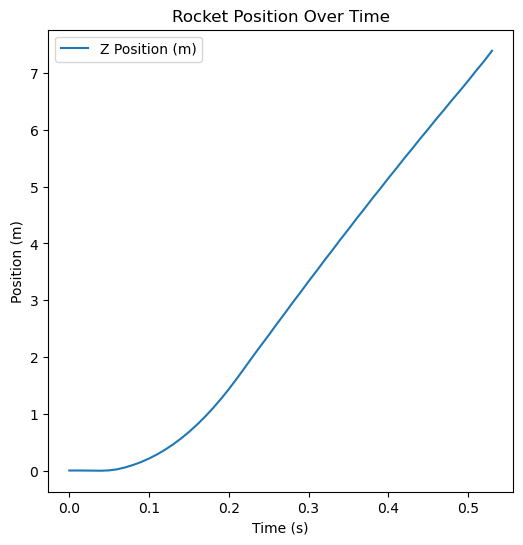

In [2]:
# Run the simulation
t_final = 1  # total simulation time in seconds
dt = 0.01  # time step in seconds
rocket_state = simulate_rocket(t_final, dt, params)
# Plot the results
plt.figure(figsize=(6, 6))
# plt.plot(np.arange(0, t_final, dt), rocket_state[0, :], label='X Position (m)')
# plt.plot(np.arange(0, t_final, dt), rocket_state[1, :], label='Y Position (m)')
plt.plot(np.arange(0, t_final, dt), rocket_state[2, :], label='Z Position (m)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Rocket Position Over Time')
plt.legend()

plt.show()

In [23]:
print(rocket_state[12])


[ 0.00000000e+000  7.60923035e+000  1.52184607e+001  2.28275598e+001
  3.04354116e+001  3.80393183e+001  4.56403683e+001  5.32657872e+001
  6.09903073e+001  6.89238239e+001  7.71359404e+001  8.55380950e+001
  9.37764394e+001  1.01272877e+002  1.07573568e+002  1.12956956e+002
  1.18829545e+002  1.27277061e+002  1.39532922e+002  1.53604566e+002
  1.62625664e+002  1.59429948e+002  1.51370198e+002  1.63939179e+002
  1.86212226e+002  2.04152783e+002  2.05231954e+002  1.98474098e+002
  1.96146842e+002  2.17320019e+002  2.40546196e+002  2.46169302e+002
  2.44845220e+002  2.42851390e+002  2.47837275e+002  2.70953362e+002
  2.91304944e+002  2.87472646e+002  2.79501461e+002  2.91385298e+002
  3.10337504e+002  3.24182571e+002  3.29448294e+002  1.24701995e+006
  1.24702081e+006 -2.67725992e+015 -2.67725992e+015 -2.67725992e+015
  1.37670106e+077  1.70427337e+104  1.70427337e+104              nan
              nan              nan              nan              nan
              nan              nan